In [2]:
import numpy as np
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt

from pathlib import Path
import sys

CODE_DIR = Path("../../../code").resolve()
sys.path.insert(0, str(CODE_DIR))

from loaders.dataset import DatasetRefiner

/opt/anaconda3/envs/IRP311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
region_map = {'UKNegatives': 'UK',
              'USA': 'USA',
              'Russia': 'Russia',
              'Russia2': 'Russia',
              'Russia3': 'Russia',
              'Karoo': 'Karoo',
              'Brazil': 'Brazil',
              'Australia': 'Australia',
              'France': 'France',
              'Texas': 'USA',
              'UKTraining': 'Somerset',
              'EastQuantock': 'Somerset',
              'UKQuantock': 'Somerset',
              'Italy': 'Italy',
              'Morocco': 'Morocco',}

In [4]:
output_dir = '/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/'

In [9]:
pattern = r'g\d{4}_'

for dir in ['/Users/willmcmahon/Downloads/Morocco']:
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.npz'):
                data = np.load(os.path.join(root, file))
                resolution = data['res']
                positive = 0 if data['scd_pixel_fraction'] == 0 else 1
                positive_str = 'positive' if positive == 1 else 'negative'
                region = os.path.basename(os.path.dirname(os.path.join(root, file)))  # parent directory name of the specific file
                region = region_map[region]

                if 'Copy of' in file:
                    file = file.replace('Copy of ', '')

                file = file.replace('pos_', '')
                file = file.replace('neg_', '')

                # find and remove group indicator (g0001, g0002, etc.)
                file = re.sub(pattern, '', file)

                bounds = file.strip('.npz').split('_')[-4:] # last 4 in path are bounds
                for i in range(len(bounds)):
                    try:
                        bounds[i] = int(bounds[i])
                    except ValueError:
                        print(f"Could not convert {bounds[i]} to int for file {file}")


                name = f"{region}_{positive_str}_{file}"

                np.savez_compressed(os.path.join(output_dir, name),
                        image=data['image'], 
                        layer_names=data['layer_names'],
                        res=resolution,
                        labels = data['labels'],
                        scd_pixel_fraction=data['scd_pixel_fraction'],
                        positive=positive,
                        region=region,
                        bounds = tuple(bounds))
            

# Dataset Analysis


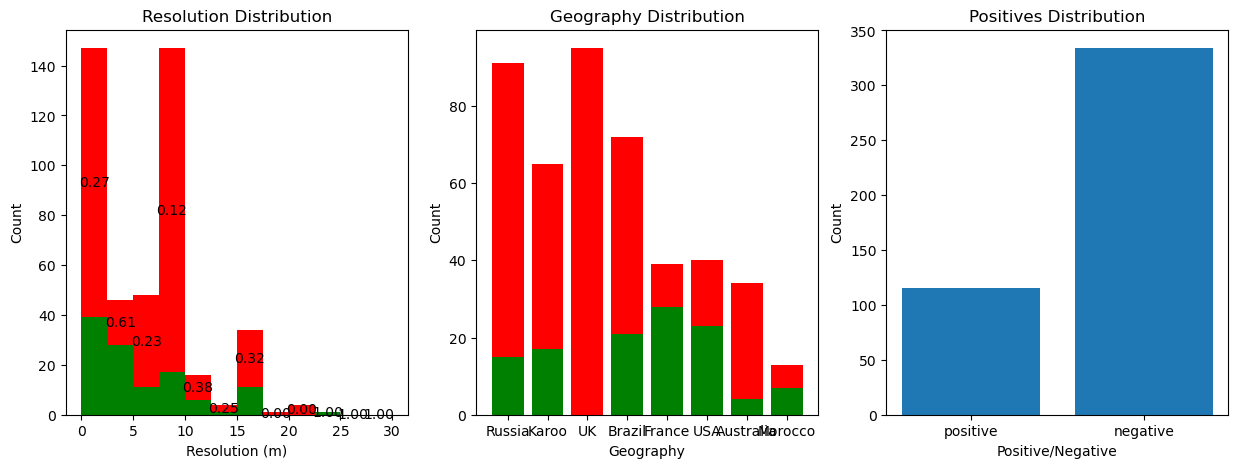

In [10]:
import sys
from pathlib import Path
CODE_DIR = Path("../../../code").resolve()
sys.path.insert(0, str(CODE_DIR))

from loaders.dataset import DatasetWrapper, DatasetRefiner

dset = DatasetWrapper('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/')
trainset, testset = dset.generate_dataset(test_region='Somerset')

dset.plot_distribution()


# refine dataset

In [5]:
refiner = DatasetRefiner('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/', 'Morocco')

In [7]:
refiner.fix_duplicates()

In [8]:
refiner.tiles

[PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_negative_695443_3655380_698003_3657940.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_positive_752229_3745445_756894_3750110.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_positive_714023_3750809_717249_3754035.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_negative_722547_3757289_727845_3762587.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_positive_714514_3713028_717074_3715588.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_positive_716976_3740291_721911_3745227.npz'),
 PosixPath('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/Morocco_negative_733670_3719610_737011_3722951.npz'),
 PosixPath('/Users/willmcma

# Veto Dataset

In [2]:
region_map = {'Namibia': 'Namibia',
              'Russia': 'Russia',
              'Brazil': 'Brazil',
              'France1': 'France',
              'Texas': 'USA',
              'France2': 'France',
              'UKNeg2': 'UK',
              'UKNeg': 'UK',
              'Italy': 'Italy',}

In [26]:
output_dir = 'C:/Users/Will/Documents/PhD/SCDs/scd-detection/data/Veto_dataset/'

labels = {'reject': 0,
          'retain': 0}

regions = {}

context_widths = []
tile_sizes = {'rgb': [],
              'dem': []}

for dir in ['C:/Users/Will/Downloads/VetoTiles']:
    for root, dirs, files in os.walk(dir):
        for i, file in enumerate(files):
            if file.endswith('.npz'):
                data = np.load(os.path.join(root, file))
                label = data['label']

                if label == 1:
                    labels['retain'] += 1
                else:
                    labels['reject'] += 1

                rgb = True if data['rgb'] is not None else False
                region = Path(root, file).parents[1].name # parent directory name of the specific file
                region = region_map[region]
                
                if region not in regions:
                    regions[region] = 0
                regions[region] += 1

                bounds = data['bounds']
                context_widths.append(data['context_width_m'])
                with np.load(os.path.join(root, file)):
                    tile_sizes['rgb'].append(data['rgb'].shape[1])
                    tile_sizes['dem'].append(data['dem_context'].shape[1])

                name = f"Veto_{region}_{i}"

                np.savez_compressed(os.path.join(output_dir, name),
                        dem=data['dem_context'], 
                        mask=data['mask'],
                        rgb=data['rgb'] if rgb else None,
                        rgb_flag=rgb,
                        label=data['label'],
                        region=region,
                        bounds=bounds)

## analyse data from this!


In [ ]:
display(np.unique(np.asarray(tile_sizes['rgb'])))
display(np.unique(np.asarray(tile_sizes['dem'])))

array([96])

array([224])

In [33]:
display(regions)

{'Brazil': 160,
 'France': 158,
 'Italy': 80,
 'Namibia': 57,
 'Russia': 363,
 'USA': 32,
 'UK': 11}

(array([217.,  60.,  69.,  60.,  60.,  60.,  58.,  40.,  43., 194.]),
 array([ 768.        , 1091.19995117, 1414.40002441, 1737.60009766,
        2060.80004883, 2384.        , 2707.20019531, 3030.40014648,
        3353.60009766, 3676.80004883, 4000.        ]),
 <BarContainer object of 10 artists>)

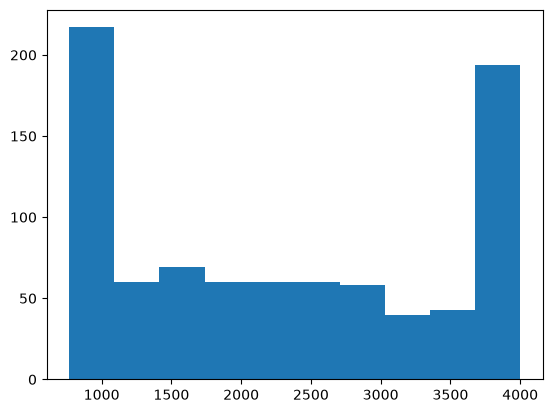

In [ ]:
plt.hist(context_widths)

In [35]:
display(labels)

{'reject': 276, 'retain': 585}